170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


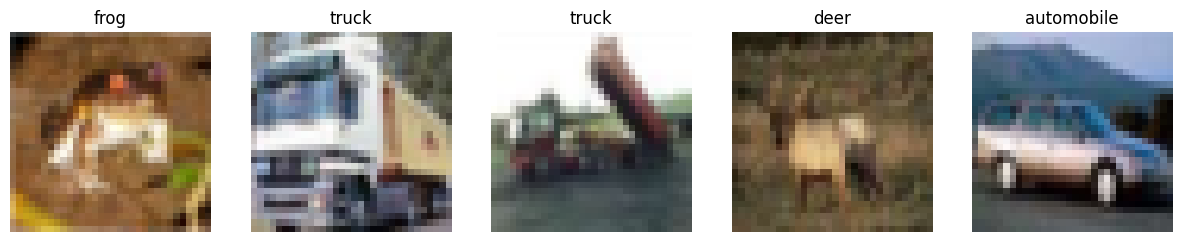

In [1]:
# %% Veri Setini içeri aktarma ve preprocessimg : normalizasyon, one - hot encoding
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # veri setimiz
from tensorflow.keras.utils import to_categorical #encoding
from tensorflow.keras.models import Sequential #sirali model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #Feature extraction ve classification
from tensorflow.keras.optimizers import RMSprop #optimizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator #data augmentation (veri arttırma)

from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")



#cifar-10 veri setini yükle
(x_train,y_train) , (x_test,y_test)  = cifar10.load_data()
x_train=x_train.astype("float32")/255
x_test=x_test.astype("float32")/255

#görselleştirme
class_labels=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
fig, axes=plt.subplots(1,5,figsize=(15,10))

for i in range(5):
  axes[i].imshow(x_train[i])
  axes[i].set_title(class_labels[y_train[i][0]])
  axes[i].axis("off")
plt.show()

#one-hot-encoding
y_train= to_categorical(y_train, 10) # 10 class var bu nedenle 10 yazıyoruz
y_test= to_categorical(y_test, 10) # 10 class var bu nedenle 10 yazıyoruz



In [2]:
# %% Veri Artirimi (Data Augmentation)
# elimizdeki görüntüleri yakınlaştırıp, uzaklaştırarak, sağa ve sola kaydırararak,gürültü ekleyerek görüntüleri çoğaltacağız. böylece gerçek hayatta tespit için daha iyi model elde edilecek.

datagen= ImageDataGenerator(
    rotation_range=20, #20 dereceye kadar dondurme saglar
    width_shift_range=0.2, # goruntuyu yatayla %20 kaydirma
    height_shift_range=0.2, # goruntuyu dikeyde %20 kaydirma
    shear_range=0.2, # goruntu uzerinde kaydirma
    zoom_range=0.2, # goruntu yakinlastirma ve uzaklastirma
    horizontal_flip=True, #goruntunun simetrigini alma
    fill_mode="nearest" # bos alanlari doldurmak icin en yakin pixel degerlerini kullan
)
datagen.fit(x_train) # data augmentation'i egitim verileri uzerinde uygula

In [3]:
# %% Create,compile and train model

#cnn modeli oluştur (base model)
model= Sequential()

#FEAUTERE Extraction : conv-> RELU-> conv-> RELU ->POOL-> DROPOUT

model.add(Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(32,32,3)))
model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25)) #bağlantıların %25'ini rasgele kapat

#FEAUTERE Extraction : conv-> RELU-> conv-> RELU ->POOL-> DROPOUT
model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
model.add(Conv2D(62,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# classification: FLATTEİ DENSE, RELU, DROPOUT, DENSE(OUTPUT LAYER)

model.add(Flatten()) #vektor olustur
model.add(Dense(512,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10,activation="softmax"))

model.summary()

#model derleme
model.compile(optimizer=RMSprop(learning_rate=0.0001,decay=1e-6),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

#model training
history = model.fit(datagen.flow(x_train,y_train,batch_size=64),#data augmentation uygulanmış veri akışı
          epochs=50,
          validation_data=(x_test,y_test),# train split yapmak yerine doğrulamayı test ile yapacağız.
          )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 62)     │        35,774 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 62)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 62)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2232)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,143,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,840 (4.63 MB)

 Trainable params: 1,212,840 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.2386 - loss: 2.0460 - val_accuracy: 0.3727 - val_loss: 1.7946
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.3277 - loss: 1.8270 - val_accuracy: 0.4126 - val_loss: 1.6308
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.3612 - loss: 1.7308 - val_accuracy: 0.4384 - val_loss: 1.5465
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3860 - loss: 1.6713 - val_accuracy: 0.4580 - val_loss: 1.5068
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4057 - loss: 1.6242 - val_accuracy: 0.4561 - val_loss: 1.5143
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4243 - loss: 1.5798 - val_accuracy: 0.4911 - val_loss: 1.4150
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4396 - loss: 1.5428 - val_accuracy: 0.4914 - val_loss: 1.4253
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4559 - loss: 1.5117 - 

In [4]:
# %% Test model and evaluate performance

#modelin test seti üzerinden tahmin yapalim

y_pred=model.predict(x_train) # burada her sınıfa bir olasılık belirliyor. toplam olasılık 1 olacak şekilde.
y_pred_class=np.argmax(y_pred,axis=1) # en büyük olasılığı alarak tahmin edilen sınıfları tespit ediyoruz. (düşük olasıklarda olsa en büyükse alınır)
y_true=np.argmax(y_train,axis=1) # gerçek sınıfları tespit ediyoruz. decoding yaptık aslında




1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


              precision    recall  f1-score   support

    airplane       0.75      0.81      0.78      5000
  automobile       0.80      0.90      0.85      5000
        bird       0.76      0.52      0.62      5000
         cat       0.68      0.35      0.47      5000
        deer       0.75      0.56      0.64      5000
         dog       0.68      0.62      0.65      5000
        frog       0.55      0.92      0.69      5000
       horse       0.77      0.78      0.77      5000
        ship       0.85      0.85      0.85      5000
       truck       0.73      0.90      0.81      5000

    accuracy                           0.72     50000
   macro avg       0.73      0.72      0.71     50000
weighted avg       0.73      0.72      0.71     50000



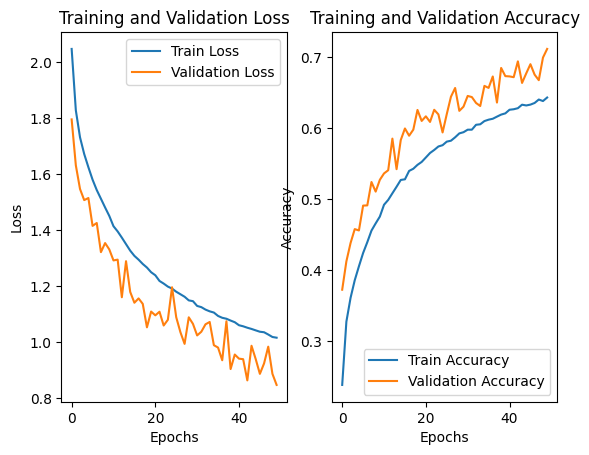

In [6]:
#classification report hesapla
print(classification_report(y_true,y_pred_class,target_names=class_labels))
#loss grafikleri
plt.figure()
plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()